# BDD100K Four-Class Data Preparation and Validation Notebook

This notebook documents the data preparation stage of our driving-scene detection project. The goal is to convert the original BDD100K per-image JSON annotations into a cleaner four-class YOLO detection format and to verify that the converted labels remain both geometrically and numerically correct.

The final detection setup uses four classes:

- **0: vehicle**
- **1: person**
- **2: traffic sign**
- **3: traffic light**

Rather than treating this notebook as a loose collection of checks, we organize it as a complete preprocessing pipeline: dataset inspection, raw-annotation understanding, class simplification, JSON-to-YOLO conversion, post-conversion validation, and final dataset summary.

## Contents

1. Project motivation  
2. Processing pipeline overview  
3. Environment setup and dataset overview  
4. Original BDD100K annotation structure  
5. Raw annotation visualization  
6. Class distribution before merging  
7. Four-class design and mapping  
8. Conversion logic and implementation  
9. Conversion output summary  
10. Post-conversion visualization  
11. Numerical sanity checks  
12. Final dataset statistics  
13. Interpretation and downstream implications


## 1. Project Motivation

This notebook focuses on the data preparation stage of our driving-scene detection project. Our goal is not only to read the BDD100K annotations, but also to reorganize them into a cleaner and more task-oriented format that can support later model training and downstream analysis.

Although BDD100K provides rich object annotations, its original labels are relatively fine-grained and contain many categories that are not all equally important for our project. For our task, we want to build a simplified detection dataset that keeps the most relevant road-user and traffic-control information while reducing unnecessary label complexity.

To achieve this, we convert the original BDD100K object annotations into a four-class YOLO detection format:
- vehicle
- person
- traffic sign
- traffic light

This simplified label structure makes the dataset easier to train on, easier to inspect, and more consistent with the downstream goal of scene understanding and risk-related analysis. In this notebook, we therefore focus on three questions:

1. What does the original BDD100K annotation structure look like?  
2. How do we map the original labels into our four-class design?  
3. How can we verify that the converted YOLO labels remain geometrically and numerically correct?

## 2. Overview of the Processing Pipeline

The preprocessing workflow in this notebook is organized into several stages, and each stage serves a specific purpose in building a reliable four-class detection dataset.

- **Dataset inspection** confirms the folder structure, annotation files, and image-label correspondence before conversion begins.
- **Original annotation inspection** shows how BDD100K stores object categories and bounding boxes.
- **Raw annotation visualization** gives a geometric reference before any class merging or coordinate conversion is applied.
- **Class distribution analysis** motivates why several original categories are merged into broader groups.
- **Four-class remapping** defines how the selected BDD100K categories are reduced into our target label space.
- **YOLO conversion** transforms each valid BDD100K bounding box into normalized YOLO format.
- **Post-conversion visualization** checks whether the converted labels still align with the correct objects in the images.
- **Numerical sanity checks** verify that the converted labels satisfy valid YOLO constraints.
- **Final statistics** summarize the resulting dataset after filtering and conversion.

Together, these stages ensure that the final dataset is not only reformatted, but also interpretable, verifiable, and ready for later model training.

## 3. Environment Setup and Dataset Overview

We first import the required libraries and define the dataset paths. A separate output directory is used for the converted four-class dataset so that old label versions are not mixed with the current conversion.

In [ ]:
from pathlib import Path
import json
import shutil
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path(".")
IMG_ROOT = ROOT / "bdd100k_images_100k" / "100k"
LBL_ROOT = ROOT / "bdd100k_labels" / "100k"

# A separate output directory is used for the four-class dataset.
# This prevents old label versions from being mixed with the current conversion.
OUT_ROOT = ROOT / "data_4class" / "data"

SPLITS = ["train", "val", "test"]

print("ROOT exists:", ROOT.exists())
print("Image root exists:", IMG_ROOT.exists())
print("Label root exists:", LBL_ROOT.exists())
print("Output root:", OUT_ROOT)


ROOT exists: True
Image root exists: True
Label root exists: True
Output root: data_4class\data


## 1. Dataset Overview

The local copy of BDD100K is organized by split (`train`, `val`, and optionally `test`). Each image has a corresponding JSON annotation file. The following inspection confirms that the image folders, label folders, and output directory for converted YOLO labels are available.


In [ ]:
def count_files(folder, exts):
    if not folder.exists():
        return 0
    exts = {e.lower() for e in exts}
    return sum(1 for p in folder.iterdir() if p.suffix.lower() in exts)

rows = []
for split in SPLITS:
    img_dir = IMG_ROOT / split
    lbl_dir = LBL_ROOT / split
    rows.append({
        "split": split,
        "num_images": count_files(img_dir, [".jpg", ".jpeg", ".png"]),
        "num_json_labels": count_files(lbl_dir, [".json"]),
        "image_dir": str(img_dir),
        "label_dir": str(lbl_dir),
    })

df_overview = pd.DataFrame(rows)
df_overview

,split,num_images,num_json_labels,image_dir,label_dir
0,train,70000,70000,bdd100k_images_100k\100k\train,bdd100k_labels\100k\train
1,val,10000,10000,bdd100k_images_100k\100k\val,bdd100k_labels\100k\val
2,test,20000,20000,bdd100k_images_100k\100k\test,bdd100k_labels\100k\test


The table above verifies the local dataset structure. Image counts and JSON counts should be consistent at the split level because each image is paired with one annotation file.


## 2. Original BDD100K Annotation Format

Each BDD100K image is associated with a per-image JSON file. The bounding-box annotations used for detection are stored under:

- `frames[0]["objects"]`
- object category in `category`
- bounding box coordinates in `box2d`

The JSON file may also contain other annotation types, including lane and area annotations. Those entries are not part of the four-class detection task and are excluded during conversion.


In [ ]:
def get_sample_json(split="train"):
    lbl_dir = LBL_ROOT / split
    json_files = sorted(lbl_dir.glob("*.json"))
    return json_files[0] if json_files else None

sample_json = get_sample_json("train")
print("Sample JSON:", sample_json)

if sample_json is not None:
    with open(sample_json, "r", encoding="utf-8") as f:
        sample_data = json.load(f)

    print("Top-level keys:", list(sample_data.keys()))
    print("Number of frames:", len(sample_data.get("frames", [])))

    if sample_data.get("frames"):
        frame0 = sample_data["frames"][0]
        print("Frame 0 keys:", list(frame0.keys()))
        print("Number of objects in frame 0:", len(frame0.get("objects", [])))

Sample JSON: bdd100k_labels\100k\train\0000f77c-6257be58.json
Top-level keys: ['name', 'frames', 'attributes']
Number of frames: 1
Frame 0 keys: ['timestamp', 'objects']
Number of objects in frame 0: 11


In [ ]:
# Print a few example objects so we can inspect the raw annotation structure
if sample_json is not None:
    objects = sample_data.get("frames", [{}])[0].get("objects", [])
    for i, obj in enumerate(objects[:5]):
        print(f"Object {i}:")
        print(json.dumps(obj, indent=2)[:1200])
        print("-" * 80)

Object 0:
{
  "category": "traffic light",
  "id": 0,
  "attributes": {
    "occluded": false,
    "truncated": false,
    "trafficLightColor": "green"
  },
  "box2d": {
    "x1": 1125.902264,
    "y1": 133.184488,
    "x2": 1156.978645,
    "y2": 210.875445
  }
}
--------------------------------------------------------------------------------
Object 1:
{
  "category": "traffic light",
  "id": 1,
  "attributes": {
    "occluded": false,
    "truncated": false,
    "trafficLightColor": "green"
  },
  "box2d": {
    "x1": 1156.978645,
    "y1": 136.637417,
    "x2": 1191.50796,
    "y2": 210.875443
  }
}
--------------------------------------------------------------------------------
Object 2:
{
  "category": "traffic sign",
  "id": 2,
  "attributes": {
    "occluded": false,
    "truncated": false,
    "trafficLightColor": "none"
  },
  "box2d": {
    "x1": 1101.731743,
    "y1": 211.122087,
    "x2": 1170.79037,
    "y2": 233.566141
  }
}
-----------------------------------------------

### Annotation fields used for conversion

Only object entries that satisfy both of the following conditions are retained:

1. the object category belongs to the selected target set;
2. the object contains a valid `box2d` field.

This prevents non-detection annotations from being written into the YOLO label files.


## 3. Visualization of Original BDD100K Bounding Boxes

The following examples show the source annotations directly from the original JSON files. Displaying the raw BDD100K boxes establishes the geometric baseline before any class merging or format conversion.

Different original categories are shown in different colors to preserve the fine-grained label structure of the source annotations.


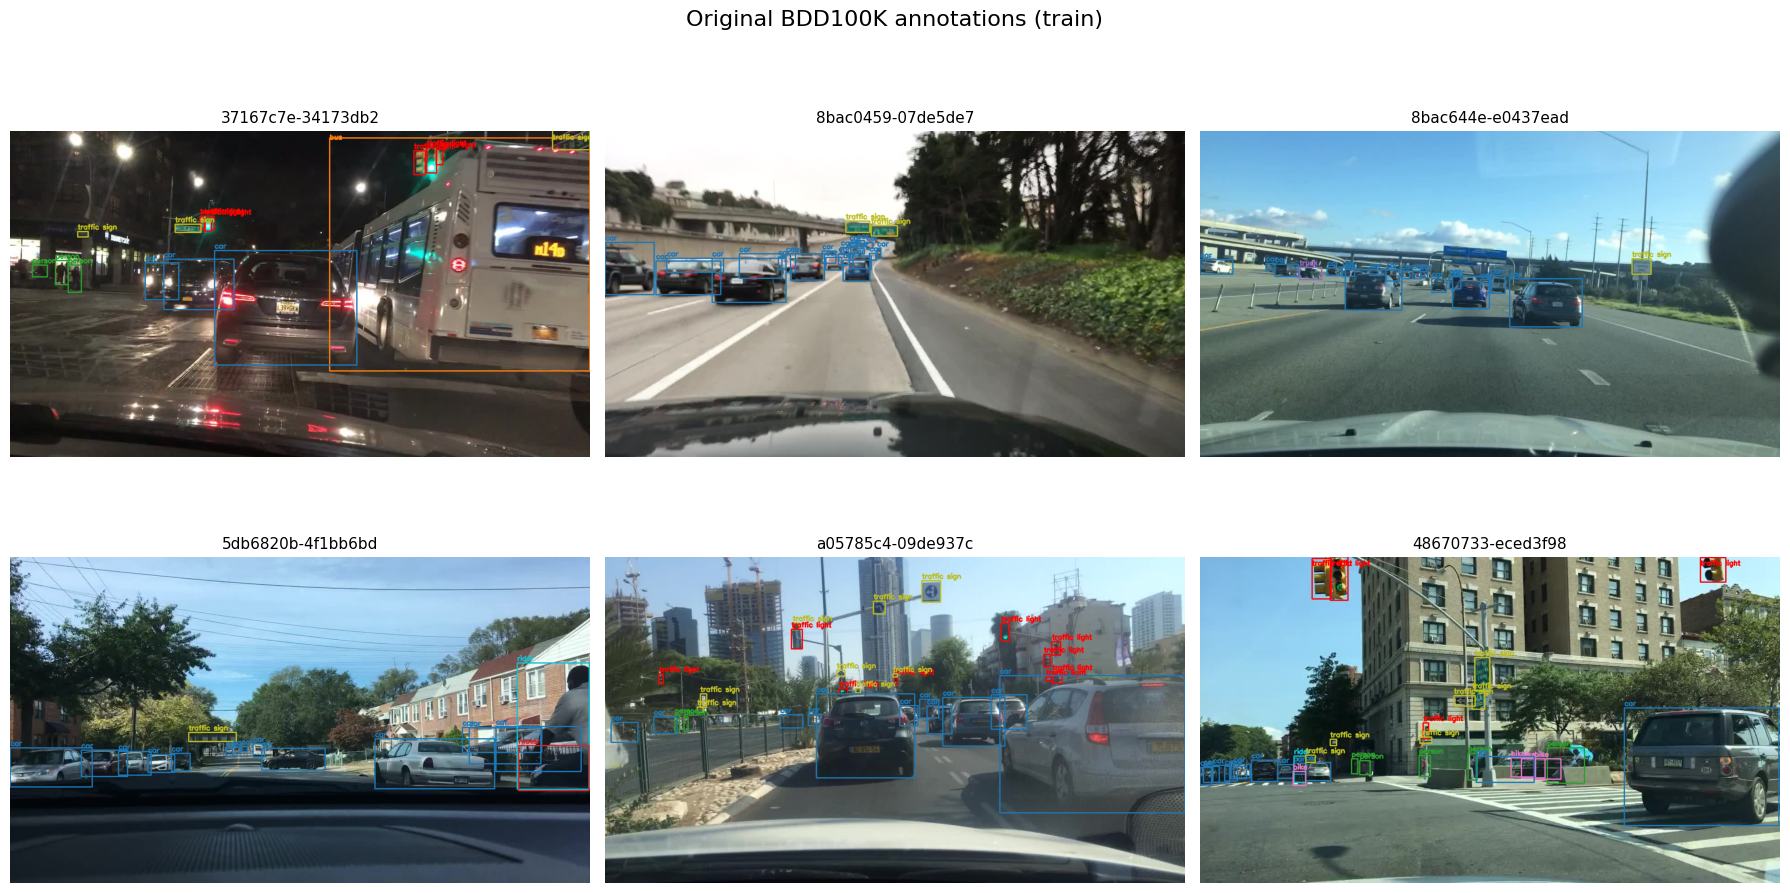

In [ ]:
import random
import math

TARGET_CATEGORIES = {
    "car", "bus", "truck", "train", "bike", "motor",
    "person", "rider", "traffic sign", "traffic light"
}

FOUR_CLASS_MAP = {
    "car": 0,
    "bus": 0,
    "truck": 0,
    "train": 0,
    "bike": 0,
    "motor": 0,
    "person": 1,
    "rider": 1,
    "traffic sign": 2,
    "traffic light": 3,
}

FOUR_CLASS_NAMES = {
    0: "vehicle",
    1: "person",
    2: "traffic sign",
    3: "traffic light",
}

ORIGINAL_COLOR_MAP = {
    "car": (31, 119, 180),
    "bus": (255, 127, 14),
    "truck": (148, 103, 189),
    "train": (140, 86, 75),
    "bike": (227, 119, 194),
    "motor": (214, 39, 40),
    "person": (44, 160, 44),
    "rider": (23, 190, 207),
    "traffic sign": (188, 189, 34),
    "traffic light": (255, 0, 0),
}

def find_image_for_json(json_path, split):
    stem = json_path.stem
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = IMG_ROOT / split / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None

def render_original_bdd_boxes(json_path, split="train", only_target_categories=True):
    img_path = find_image_for_json(json_path, split)
    if img_path is None:
        return None, f"No matching image found for {json_path.name}"

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    img = cv2.imread(str(img_path))
    if img is None:
        return None, f"Cannot read image {img_path.name}"

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    objects = data.get("frames", [{}])[0].get("objects", [])

    for obj in objects:
        category = obj.get("category")
        box2d = obj.get("box2d")
        if not box2d:
            continue
        if only_target_categories and category not in TARGET_CATEGORIES:
            continue

        x1 = int(box2d["x1"])
        y1 = int(box2d["y1"])
        x2 = int(box2d["x2"])
        y2 = int(box2d["y2"])
        color = ORIGINAL_COLOR_MAP.get(category, (255, 255, 255))

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img,
            category,
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    return img, json_path.stem

def show_original_bdd_grid(split="train", n=6, cols=3, only_target_categories=True, seed=42):
    json_dir = LBL_ROOT / split
    json_files = list(json_dir.glob("*.json"))

    if len(json_files) == 0:
        print(f"No json files found in {json_dir}")
        return []

    random.seed(seed)
    sample_files = random.sample(json_files, min(n, len(json_files)))

    rows = math.ceil(len(sample_files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.flatten():
        ax.axis("off")

    for ax, json_path in zip(axes.flatten(), sample_files):
        img, title = render_original_bdd_boxes(
            json_path,
            split=split,
            only_target_categories=only_target_categories
        )
        if img is not None:
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
        else:
            ax.text(0.5, 0.5, title, ha="center", va="center")
        ax.axis("off")

    plt.suptitle(f"Original BDD100K annotations ({split})", fontsize=16)
    plt.tight_layout()
    plt.show()
    return sample_files

sample_jsons = show_original_bdd_grid(split="train", n=6, cols=3, only_target_categories=True, seed=21)
sample_json = sample_jsons[0] if sample_jsons else None


The examples above show the original BDD100K box geometry before class merging. These figures serve as the reference point for the converted YOLO labels shown later in the notebook.


In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

TARGET_CATEGORIES = {
    "car", "bus", "truck", "train", "bike", "motor",
    "person", "rider", "traffic sign", "traffic light"
}

def count_original_classes(split="train"):
    json_dir = LBL_ROOT / split
    counter = Counter()

    for json_path in json_dir.glob("*.json"):
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        objects = data.get("frames", [{}])[0].get("objects", [])
        for obj in objects:
            category = obj.get("category")
            box2d = obj.get("box2d")
            if not box2d:
                continue
            if category in TARGET_CATEGORIES:
                counter[category] += 1

    return counter

original_counter = count_original_classes(split="train")
original_df = pd.DataFrame(
    sorted(original_counter.items(), key=lambda x: x[1], reverse=True),
    columns=["class", "count"]
)

print(original_df)

           class   count
0            car  714121
1   traffic sign  239961
2  traffic light  186301
3         person   91435
4          truck   30012
5            bus   11688
6           bike    7227
7          rider    4522
8          motor    3002
9          train     136


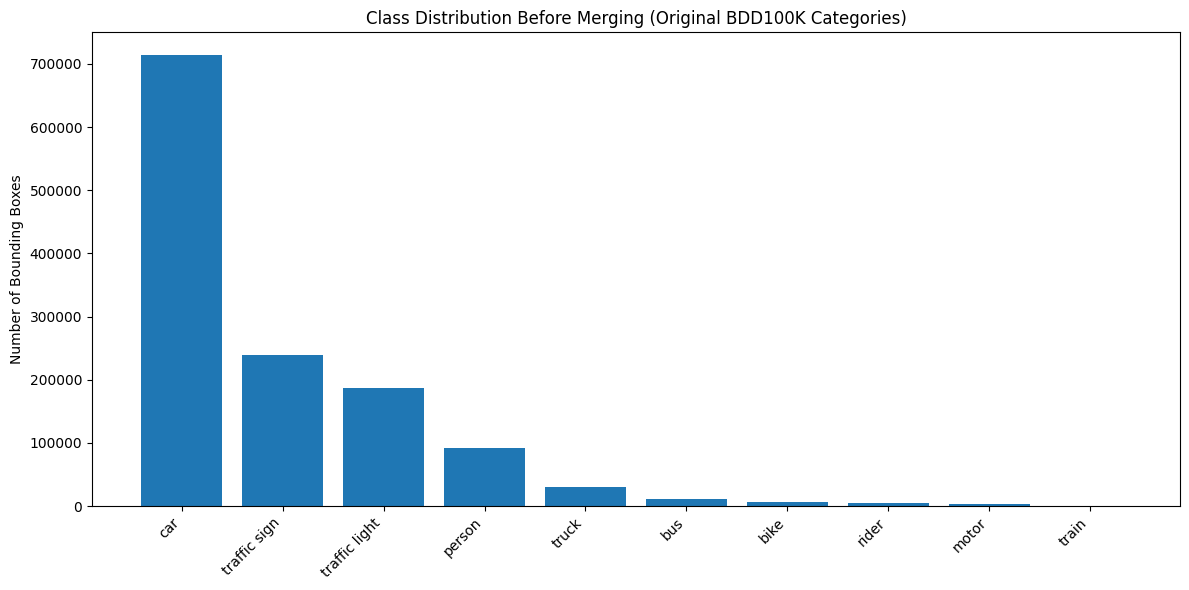

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(original_df["class"], original_df["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Bounding Boxes")
plt.title("Class Distribution Before Merging (Original BDD100K Categories)")
plt.tight_layout()
plt.show()

The original target categories in BDD100K exhibit a noticeably imbalanced distribution. Vehicle-related classes account for a large proportion of the annotated objects, while several fine-grained categories, such as train, bike, motor, and rider, appear much less frequently. This long-tailed distribution increases the difficulty of training a detector that must distinguish all categories separately.

## 4. Final Four-Class Mapping

The conversion step applies the following class merge:

- multiple vehicle-related categories → **vehicle**
- `person` and `rider` → **person**
- `traffic sign` remains separate
- `traffic light` remains separate

The table below lists the exact mapping from raw BDD100K categories to final class IDs.


In [ ]:
mapping_rows = []
for raw_cls, mapped_id in FOUR_CLASS_MAP.items():
    mapping_rows.append({
        "raw_category": raw_cls,
        "mapped_id": mapped_id,
        "mapped_name": FOUR_CLASS_NAMES[mapped_id]
    })

pd.DataFrame(mapping_rows).sort_values(["mapped_id", "raw_category"]).reset_index(drop=True)

,raw_category,mapped_id,mapped_name
0,bike,0,vehicle
1,bus,0,vehicle
2,car,0,vehicle
3,motor,0,vehicle
4,train,0,vehicle
5,truck,0,vehicle
6,person,1,person
7,rider,1,person
8,traffic sign,2,traffic sign
9,traffic light,3,traffic light


The mapping preserves the main road participants and traffic-control objects while reducing label sparsity. This representation is compact enough for robust detection and retains the semantic elements needed by the downstream risk-analysis module.


## 5. Conversion Logic: From BDD100K JSON to YOLO TXT

YOLO stores each object using the format:

`class_id x_center y_center width height`

All coordinates are normalized by image width and image height. Starting from the original BDD100K bounding box \((x_1, y_1, x_2, y_2)\), the converted YOLO coordinates are:

$
x_c =
rac{x_1 + x_2}{2W}, \quad
y_c =
rac{y_1 + y_2}{2H}, \quad
w =
rac{x_2 - x_1}{W}, \quad
h =
rac{y_2 - y_1}{H}
$

where \(W\) and \(H\) denote image width and height.


In [ ]:
def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def clamp(v, lo, hi):
    return max(lo, min(v, hi))

def load_image_size(img_path: Path):
    with Image.open(img_path) as img:
        return img.size  # (w, h)

def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    x1 = clamp(float(x1), 0, img_w)
    x2 = clamp(float(x2), 0, img_w)
    y1 = clamp(float(y1), 0, img_h)
    y2 = clamp(float(y2), 0, img_h)

    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1

    bw = x2 - x1
    bh = y2 - y1

    if bw <= 1 or bh <= 1:
        return None

    xc = (x1 + x2) / 2.0 / img_w
    yc = (y1 + y2) / 2.0 / img_h
    w = bw / img_w
    h = bh / img_h

    if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
        return None

    return xc, yc, w, h

def get_objects_from_bdd_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    frames = data.get("frames", [])
    if not frames:
        return []
    return frames[0].get("objects", [])

## 6. Conversion Function

The conversion function reads the original image size, extracts objects from the corresponding JSON file, filters the selected categories, converts `box2d` into normalized YOLO coordinates, and writes one TXT file per image.

To avoid mixing previous label versions with the current four-class labels, the conversion utility below includes an option to clear the existing output split before writing new files.


In [ ]:
def clear_split_output(split: str):
    out_img_dir = OUT_ROOT / "images" / split
    out_lbl_dir = OUT_ROOT / "labels" / split

    if out_img_dir.exists():
        shutil.rmtree(out_img_dir)
    if out_lbl_dir.exists():
        shutil.rmtree(out_lbl_dir)

    ensure_dir(out_img_dir)
    ensure_dir(out_lbl_dir)

def convert_split(split: str, overwrite=True, clean_output=False):
    print(f"\n===== Converting {split} =====")

    img_dir = IMG_ROOT / split
    lbl_dir = LBL_ROOT / split
    out_img_dir = OUT_ROOT / "images" / split
    out_lbl_dir = OUT_ROOT / "labels" / split

    if clean_output:
        clear_split_output(split)
    else:
        ensure_dir(out_img_dir)
        ensure_dir(out_lbl_dir)

    img_files = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg")) + list(img_dir.glob("*.png")))

    total_images = 0
    total_objects = 0
    kept_boxes = 0
    skipped_no_box2d = 0
    skipped_unknown_class = 0
    skipped_invalid_box = 0
    missing_json = 0
    class_counter = Counter()

    for img_path in img_files:
        stem = img_path.stem
        json_path = lbl_dir / f"{stem}.json"
        if not json_path.exists():
            missing_json += 1
            continue

        img_w, img_h = load_image_size(img_path)
        objects = get_objects_from_bdd_json(json_path)

        yolo_lines = []
        total_images += 1

        for obj in objects:
            total_objects += 1
            category = obj.get("category")
            if category not in FOUR_CLASS_MAP:
                skipped_unknown_class += 1
                continue

            box2d = obj.get("box2d")
            if not box2d:
                skipped_no_box2d += 1
                continue

            result = xyxy_to_yolo(
                box2d["x1"], box2d["y1"], box2d["x2"], box2d["y2"], img_w, img_h
            )
            if result is None:
                skipped_invalid_box += 1
                continue

            xc, yc, w, h = result
            cls_id = FOUR_CLASS_MAP[category]
            yolo_lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
            kept_boxes += 1
            class_counter[cls_id] += 1

        out_img_path = out_img_dir / img_path.name
        out_txt_path = out_lbl_dir / f"{stem}.txt"

        if overwrite or not out_img_path.exists():
            shutil.copy2(img_path, out_img_path)

        if overwrite or not out_txt_path.exists():
            with open(out_txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(yolo_lines))

    stats = {
        "split": split,
        "images_processed": total_images,
        "total_objects": total_objects,
        "kept_boxes": kept_boxes,
        "skipped_no_box2d": skipped_no_box2d,
        "skipped_unknown_class": skipped_unknown_class,
        "skipped_invalid_box": skipped_invalid_box,
        "missing_json": missing_json,
        "class_counter": dict(class_counter),
    }

    print(stats)
    return stats

# Example execution:
# train_stats = convert_split("train", overwrite=True, clean_output=True)
# val_stats = convert_split("val", overwrite=True, clean_output=True)


In [ ]:
train_stats = convert_split("train", overwrite=True, clean_output=True)
val_stats = convert_split("val", overwrite=True, clean_output=True)
test_stats = convert_split("test", overwrite=True, clean_output=True)


===== Converting train =====
{'split': 'train', 'images_processed': 70000, 'total_objects': 1943204, 'kept_boxes': 1287922, 'skipped_no_box2d': 0, 'skipped_unknown_class': 654799, 'skipped_invalid_box': 483, 'missing_json': 0, 'class_counter': {3: 186205, 2: 239881, 0: 765919, 1: 95917}}

===== Converting val =====
{'split': 'val', 'images_processed': 10000, 'total_objects': 279289, 'kept_boxes': 185517, 'skipped_no_box2d': 0, 'skipped_unknown_class': 93711, 'skipped_invalid_box': 61, 'missing_json': 0, 'class_counter': {2: 34905, 3: 26883, 0: 109819, 1: 13910}}

===== Converting test =====
{'split': 'test', 'images_processed': 20000, 'total_objects': 555240, 'kept_boxes': 367602, 'skipped_no_box2d': 0, 'skipped_unknown_class': 187512, 'skipped_invalid_box': 126, 'missing_json': 0, 'class_counter': {2: 68987, 0: 219870, 1: 25931, 3: 52814}}


The conversion statistics report how many objects were retained, skipped, or rejected after geometric validation. These numbers provide a direct summary of the label preparation process for each split.


## 7. Visualization of Converted YOLO Labels

After conversion, the YOLO TXT labels are projected back onto the images. This step verifies that the converted boxes preserve the original geometry and that all class IDs belong to the final four-class scheme.

The figures below use a fixed color palette for the merged classes:

- **vehicle**
- **person**
- **traffic sign**
- **traffic light**


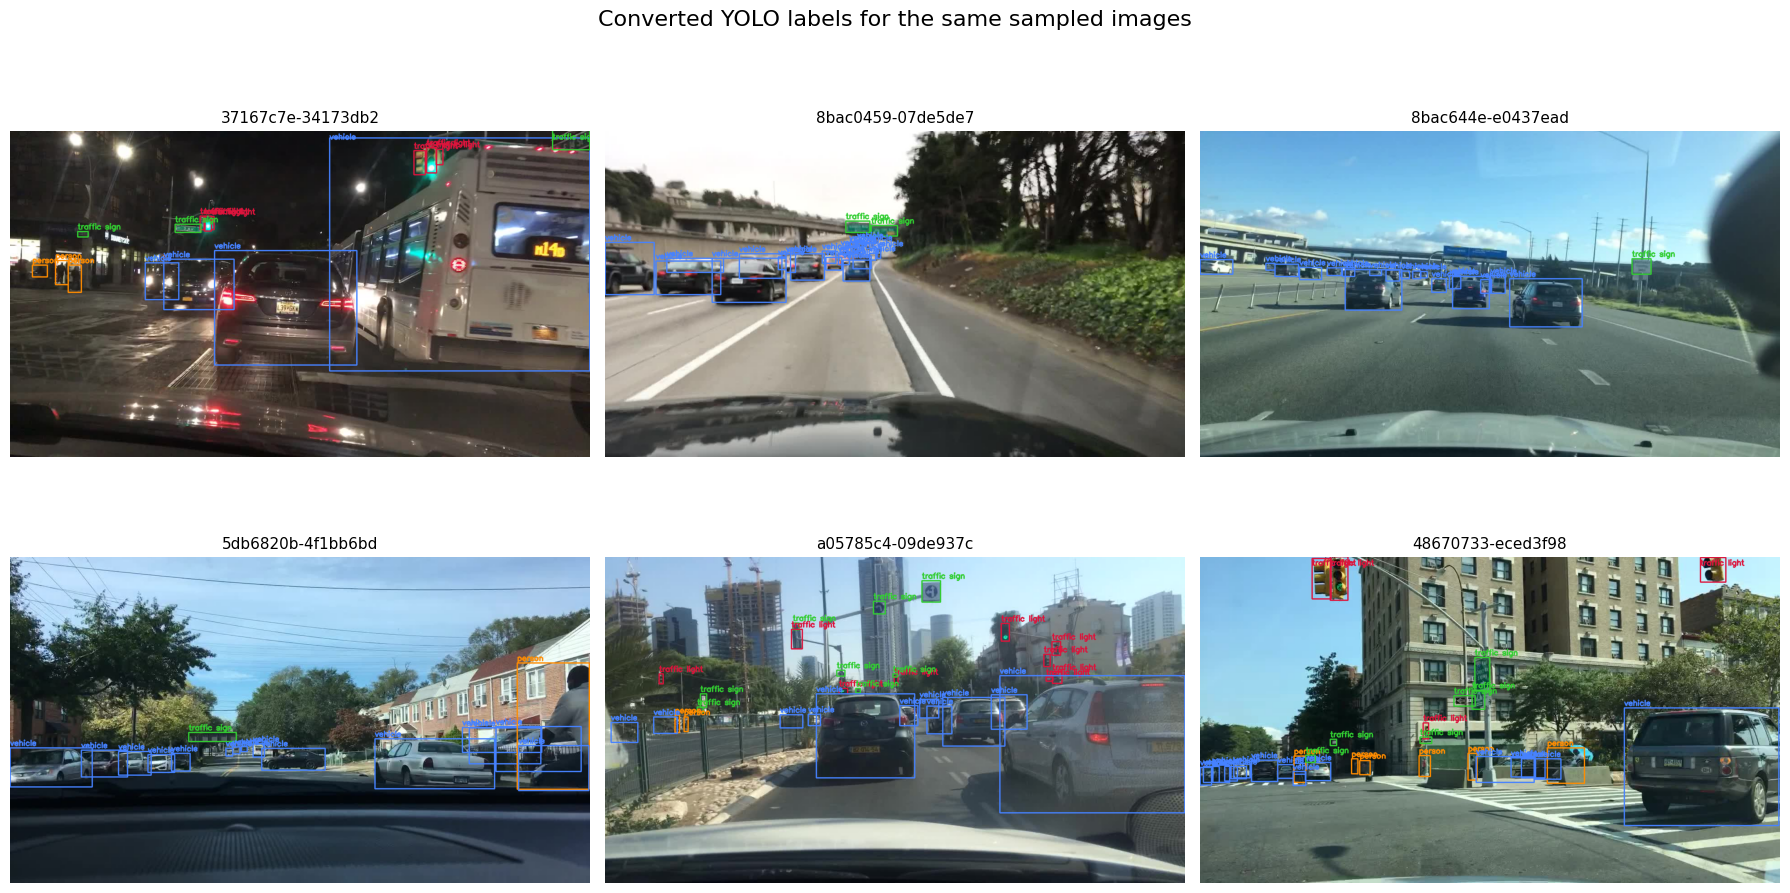

In [ ]:
FOUR_CLASS_COLOR_MAP = {
    0: (70, 130, 255),   # vehicle
    1: (255, 140, 0),    # person
    2: (50, 205, 50),    # traffic sign
    3: (220, 20, 60),    # traffic light
}

def yolo_line_to_xyxy(line, img_w, img_h):
    parts = line.strip().split()
    if len(parts) != 5:
        return None

    cls_id = int(float(parts[0]))
    xc = float(parts[1])
    yc = float(parts[2])
    w = float(parts[3])
    h = float(parts[4])

    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)

    return cls_id, x1, y1, x2, y2

def find_converted_image(stem, split="train"):
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = OUT_ROOT / "images" / split / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None

def validate_txt_class_ids(txt_path, valid_ids={0, 1, 2, 3}):
    found_ids = set()
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            found_ids.add(int(float(parts[0])))
    invalid = sorted(found_ids - set(valid_ids))
    return invalid

def render_converted_yolo_boxes(stem, split="train"):
    img_path = find_converted_image(stem, split=split)
    txt_path = OUT_ROOT / "labels" / split / f"{stem}.txt"

    if img_path is None:
        return None, f"No converted image found for {stem}"
    if not txt_path.exists():
        return None, f"No converted label found for {stem}"

    invalid_ids = validate_txt_class_ids(txt_path)
    if invalid_ids:
        return None, f"{stem} contains non-4-class ids: {invalid_ids}"

    img = cv2.imread(str(img_path))
    if img is None:
        return None, f"Cannot read image {img_path.name}"
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]

    with open(txt_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        result = yolo_line_to_xyxy(line, img_w, img_h)
        if result is None:
            continue

        cls_id, x1, y1, x2, y2 = result
        x1 = max(0, min(x1, img_w - 1))
        y1 = max(0, min(y1, img_h - 1))
        x2 = max(0, min(x2, img_w - 1))
        y2 = max(0, min(y2, img_h - 1))

        label = FOUR_CLASS_NAMES.get(cls_id, str(cls_id))
        color = FOUR_CLASS_COLOR_MAP.get(cls_id, (255, 255, 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img,
            label,
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2
        )

    return img, stem

def show_converted_yolo_grid(split="train", n=6, cols=3, seed=42):
    label_dir = OUT_ROOT / "labels" / split
    txt_files = list(label_dir.glob("*.txt"))

    if len(txt_files) == 0:
        print(f"No txt files found in {label_dir}")
        return []

    random.seed(seed)
    sample_files = random.sample(txt_files, min(n, len(txt_files)))

    rows = math.ceil(len(sample_files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.flatten():
        ax.axis("off")

    for ax, txt_path in zip(axes.flatten(), sample_files):
        stem = txt_path.stem
        img, title = render_converted_yolo_boxes(stem, split=split)
        if img is not None:
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
        else:
            ax.text(0.5, 0.5, title, ha="center", va="center")
        ax.axis("off")

    plt.suptitle(f"Converted YOLO labels ({split})", fontsize=16)
    plt.tight_layout()
    plt.show()
    return sample_files

sample_stems = [p.stem for p in sample_jsons] if sample_jsons else []
if sample_stems:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = np.array(axes).reshape(2, 3)
    for ax in axes.flatten():
        ax.axis("off")
    for ax, stem in zip(axes.flatten(), sample_stems[:6]):
        img, title = render_converted_yolo_boxes(stem, split="train")
        if img is not None:
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
        else:
            ax.text(0.5, 0.5, title, ha="center", va="center")
        ax.axis("off")
    plt.suptitle("Converted YOLO labels for the same sampled images", fontsize=16)
    plt.tight_layout()
    plt.show()


The converted examples confirm whether the four-class labels are geometrically aligned and semantically consistent. Any systematic offset, incorrect class ID, or stale label file becomes visible at this stage.


## 10. Numerical Sanity Check on YOLO TXT Values

Each converted YOLO line should satisfy:
*   $0 \le x_c \le 1$
*   $0 \le y_c \le 1$
*   $0 < w \le 1$
*   $0 < h \le 1$

In addition, the converted dataset should contain only the four expected class IDs \(\{0, 1, 2, 3\}\).


In [ ]:
def numeric_sanity_check(split="train"):
    lbl_dir = OUT_ROOT / "labels" / split
    bad = 0
    total = 0
    invalid_class_lines = 0
    bad_examples = []

    for txt_path in lbl_dir.glob("*.txt"):
        with open(txt_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f, start=1):
                parts = line.strip().split()
                if len(parts) != 5:
                    bad += 1
                    bad_examples.append((txt_path.name, i, line.strip(), "bad format"))
                    continue

                try:
                    cls_id = int(float(parts[0]))
                    xc, yc, w, h = map(float, parts[1:])
                except Exception:
                    bad += 1
                    bad_examples.append((txt_path.name, i, line.strip(), "parse error"))
                    continue

                total += 1

                if cls_id not in {0, 1, 2, 3}:
                    invalid_class_lines += 1
                    bad_examples.append((txt_path.name, i, line.strip(), "invalid class id"))

                if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    bad += 1
                    bad_examples.append((txt_path.name, i, line.strip(), "out of range"))

    summary = {
        "split": split,
        "checked_boxes": total,
        "bad_geometry_lines": bad,
        "invalid_class_lines": invalid_class_lines,
        "bad_examples_preview": bad_examples[:10],
    }
    return summary

sanity_train = numeric_sanity_check("train") if (OUT_ROOT / "labels" / "train").exists() else None
sanity_val = numeric_sanity_check("val") if (OUT_ROOT / "labels" / "val").exists() else None

sanity_train, sanity_val


({'split': 'train',
  'checked_boxes': 1287922,
  'bad_geometry_lines': 0,
  'invalid_class_lines': 0,
  'bad_examples_preview': []},
 {'split': 'val',
  'checked_boxes': 185517,
  'bad_geometry_lines': 0,
  'invalid_class_lines': 0,
  'bad_examples_preview': []})

## 11. Dataset Statistics After Conversion

The summary below reports the number of converted images, class frequencies, and the distribution of object counts per image. These statistics characterize the final training data after category filtering and class merging.


In [ ]:
def gather_converted_stats(split="train"):
    img_dir = OUT_ROOT / "images" / split
    lbl_dir = OUT_ROOT / "labels" / split

    class_counter = Counter()
    boxes_per_image = []
    num_images = 0

    for txt_path in sorted(lbl_dir.glob("*.txt")):
        num_images += 1
        cur_count = 0
        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(float(parts[0]))
                class_counter[cls_id] += 1
                cur_count += 1
        boxes_per_image.append(cur_count)

    return {
        "split": split,
        "num_images": num_images,
        "class_counter": class_counter,
        "boxes_per_image": boxes_per_image,
    }

stats_train = gather_converted_stats("train") if (OUT_ROOT / "labels" / "train").exists() else None
stats_val = gather_converted_stats("val") if (OUT_ROOT / "labels" / "val").exists() else None

stats_train, stats_val is not None

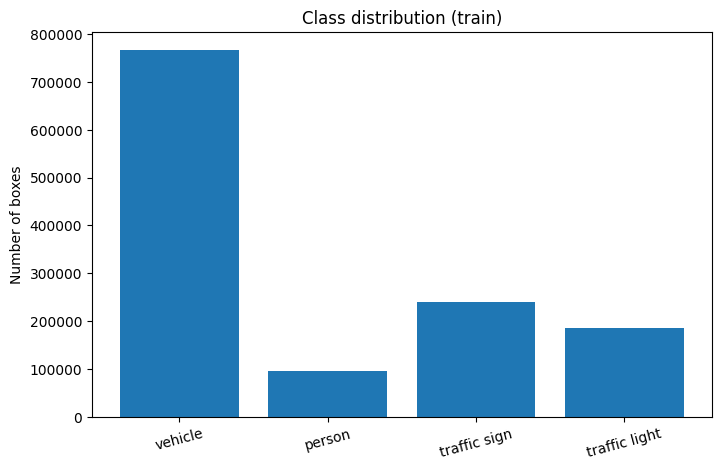

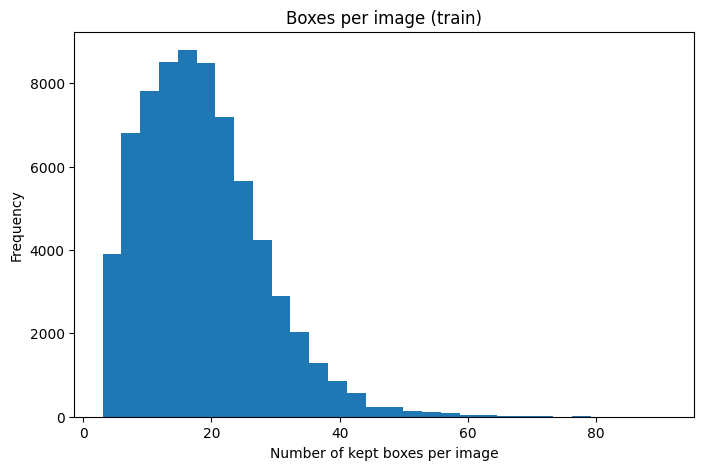

In [ ]:
def plot_class_distribution(stats, title_suffix=""):
    if stats is None:
        print("Stats not available")
        return

    labels = [FOUR_CLASS_NAMES[i] for i in sorted(FOUR_CLASS_NAMES.keys())]
    values = [stats["class_counter"].get(i, 0) for i in sorted(FOUR_CLASS_NAMES.keys())]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.title(f"Class distribution {title_suffix}".strip())
    plt.ylabel("Number of boxes")
    plt.xticks(rotation=15)
    plt.show()

def plot_boxes_per_image(stats, title_suffix=""):
    if stats is None:
        print("Stats not available")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(stats["boxes_per_image"], bins=30)
    plt.title(f"Boxes per image {title_suffix}".strip())
    plt.xlabel("Number of kept boxes per image")
    plt.ylabel("Frequency")
    plt.show()


plot_class_distribution(stats_train, "(train)")
plot_boxes_per_image(stats_train, "(train)")

In [ ]:
FOUR_CLASS_NAMES = {
    0: "vehicle",
    1: "person",
    2: "traffic sign",
    3: "traffic light",
}

def count_converted_classes(split="train"):
    label_dir = OUT_ROOT / "labels" / split
    counter = Counter()

    for txt_path in label_dir.glob("*.txt"):
        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(float(parts[0]))
                if cls_id in FOUR_CLASS_NAMES:
                    counter[FOUR_CLASS_NAMES[cls_id]] += 1

    return counter

converted_counter = count_converted_classes(split="train")
converted_df = pd.DataFrame(
    sorted(converted_counter.items(), key=lambda x: x[1], reverse=True),
    columns=["class", "count"]
)

print(converted_df)

           class   count
0        vehicle  765919
1   traffic sign  239881
2  traffic light  186205
3         person   95917


After merging semantically related categories into four broader groups, the effective support of several sparse classes is increased. In particular, multiple vehicle-related categories are consolidated into a single vehicle class, and person and rider are merged into a unified person class. Although the resulting dataset remains imbalanced, the merged label space is less sparse and more suitable for the first-stage object detection task.

## 13. Interpretation of the Results

The inspection and validation steps support the following findings:

1. the detection boxes required for this task are stored in `frames[0]["objects"]` with `box2d`;
2. the selected BDD100K categories can be merged cleanly into four classes;
3. the JSON-to-YOLO conversion preserves the original box geometry;
4. the converted labels can be checked both visually and numerically before training.


## 14. Conclusion

This notebook documents the full data preparation stage for the four-class driving-scene detector. Starting from raw BDD100K images and per-image JSON annotations, it defines the final class mapping, converts the labels into YOLO format, validates the converted outputs, and summarizes the resulting dataset statistics.

The converted dataset produced by this pipeline is the version used for subsequent model training and evaluation.
